# Gender Classification — Classification Model

## Travel Analytics: Integrating Machine Learning and MLOps in Travel

### Objective

The objective of this notebook is to develop a machine learning classification model to predict the gender of a user using the Users dataset.

The workflow will include:

1. Data loading
2. Data understanding
3. Target variable analysis
4. Feature selection
5. Data cleaning
6. Feature engineering
7. Train-test splitting
8. Data preprocessing
9. Baseline classification
10. Multiple classification models
11. Model comparison
12. Cross-validation
13. Hyperparameter tuning
14. Accuracy, Precision, Recall and F1-score
15. Confusion matrix
16. Final model selection
17. Model persistence

The final classification model will later be integrated into the overall MLOps workflow.

## 1. Business Problem

The objective is to classify users into their corresponding gender categories based on the available user-level information.

This is formulated as a supervised classification problem where:

**Target Variable:** `gender`

The model will be evaluated using classification metrics including:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [1]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Basic libraries imported successfully!")

Basic libraries imported successfully!


In [2]:
# MACHINE LEARNING LIBRARIES

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [3]:

# LOAD USERS DATASET

users = pd.read_csv("../data/users.csv")

print("Dataset loaded successfully!")
print("Shape:", users.shape)

display(users.head())

Dataset loaded successfully!
Shape: (1340, 5)


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [4]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [5]:
display(
    users.isnull()
    .sum()
    .to_frame("Missing Values")
)

,Missing Values
code,0
company,0
name,0
gender,0
age,0


In [6]:
display(users.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,1340.0,NaN,NaN,NaN,669.5,386.968991,0.0,334.75,669.5,1004.25,1339.0
company,1340,5,4You,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,1340,1338,Charlotte Johnson,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1340,3,male,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1340.0,NaN,NaN,NaN,42.742537,12.869779,21.0,32.0,42.0,54.0,65.0


In [7]:
print("Duplicate rows:", users.duplicated().sum())

Duplicate rows: 0


## 2. Target Variable Analysis

The target variable for this classification task is `gender`.

Before training classification models, the distribution of the target classes is analyzed to determine whether the dataset is balanced or imbalanced.

In [8]:

# TARGET DISTRIBUTION
print("Gender distribution:")
display(users["gender"].value_counts())

print("\nGender distribution (%):")
display(
    users["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Gender distribution:


gender
male      452
female    448
none      440
Name: count, dtype: int64


Gender distribution (%):


gender
male      33.73
female    33.43
none      32.84
Name: proportion, dtype: float64

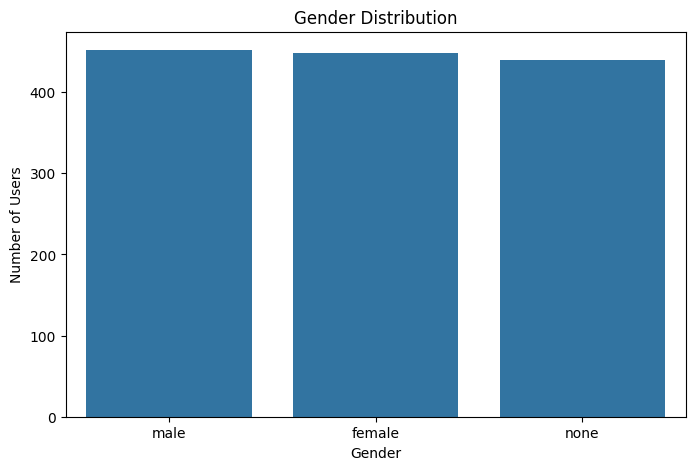

In [10]:

# GENDER DISTRIBUTION PLOT

plt.figure(figsize=(8, 5))

sns.countplot(
    data=users,
    x="gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Users")

plt.show()

In [11]:

# COMPANY DISTRIBUTION

print("Number of unique companies:",
      users["company"].nunique())

display(
    users["company"].value_counts()
)

Number of unique companies: 5


company
4You             453
Acme Factory     261
Wonka Company    237
Monsters CYA     195
Umbrella LTDA    194
Name: count, dtype: int64

In [12]:

# AGE DISTRIBUTION
print("Minimum age:", users["age"].min())
print("Maximum age:", users["age"].max())
print("Average age:", users["age"].mean())
print("Median age:", users["age"].median())

Minimum age: 21
Maximum age: 65
Average age: 42.742537313432834
Median age: 42.0


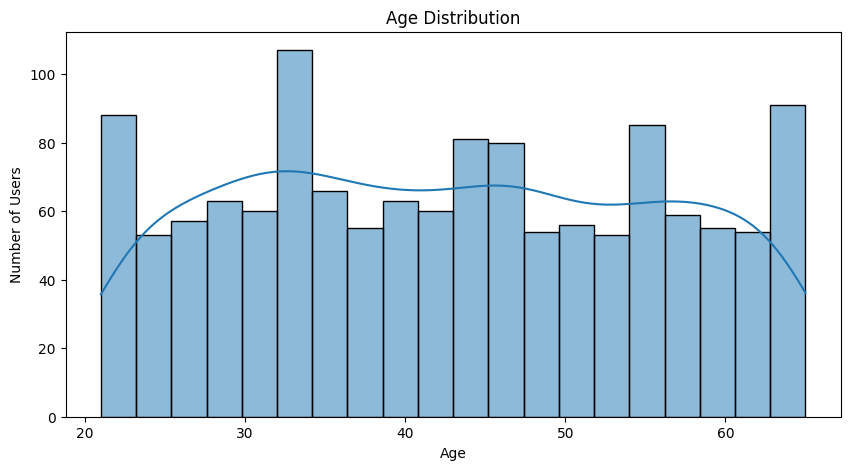

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=users,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

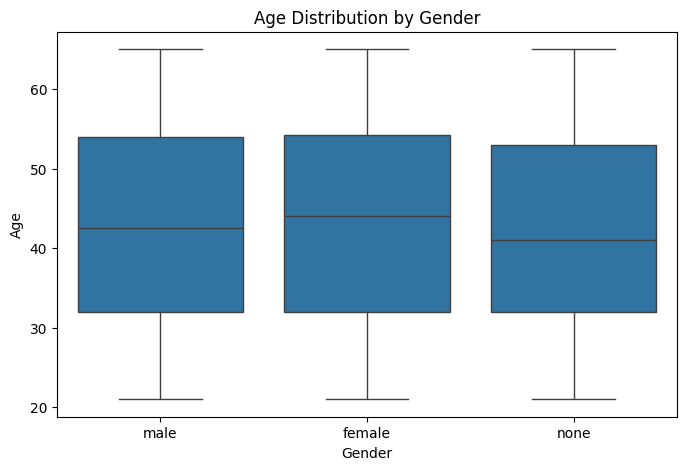

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=users,
    x="gender",
    y="age"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

## 3. Feature Selection

The following columns are considered for the initial classification model:

- `company`
- `age`

The `code` column is excluded because it is a user identifier and does not represent a meaningful predictive characteristic.

The `name` column is initially excluded to avoid relying directly on personal names as a proxy for gender. The model will therefore learn from structured user attributes.

In [15]:

# FEATURE AND TARGET SELECTION

features = [
    "company",
    "age"
]

target = "gender"

X = users[features]
y = users[target]

print("Features:", features)
print("Target:", target)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features: ['company', 'age']
Target: gender

Feature shape: (1340, 2)
Target shape: (1340,)


In [16]:

# CHECK TARGET CLASSES

print("Target classes:")
print(y.unique())

print("\nNumber of classes:", y.nunique())

Target classes:
['male' 'female' 'none']

Number of classes: 3


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (1072, 2)
Testing features : (268, 2)
Training target  : (1072,)
Testing target   : (268,)


In [18]:
numerical_features = ["age"]
categorical_features = ["company"]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age']
Categorical features: ['company']


In [19]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Classification preprocessing pipeline created successfully!")

Classification preprocessing pipeline created successfully!


In [20]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.3358208955223881


In [21]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, logistic_predictions)
)

Logistic Regression Accuracy: 0.3805970149253731


In [22]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

dt_pipeline.fit(X_train, y_train)

dt_predictions = dt_pipeline.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, dt_predictions)
)

Decision Tree Accuracy: 0.3358208955223881


In [23]:
rf_classification_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_classification_pipeline.fit(X_train, y_train)

rf_predictions = rf_classification_pipeline.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_predictions)
)

Random Forest Accuracy: 0.3208955223880597


In [24]:

# NAME ANALYSIS

print("Total users:", len(users))
print("Unique names:", users["name"].nunique())

print("\nDuplicate names:")
print(
    users["name"].duplicated().sum()
)

print("\nSample names by gender:")

for gender_class in users["gender"].unique():
    print(f"\n--- {gender_class} ---")
    display(
        users.loc[
            users["gender"] == gender_class,
            ["name", "gender"]
        ].head(10)
    )

Total users: 1340
Unique names: 1338

Duplicate names:
2

Sample names by gender:

--- male ---


,name,gender
0,Roy Braun,male
1,Joseph Holsten,male
6,Jesse Decelle,male
10,Melvin Lovejoy,male
12,David Thomas,male
14,John Cody,male
19,John Bennett,male
23,Leslie Sandoval,male
24,Calvin Cuellar,male
27,Sean Pearson,male



--- female ---


,name,gender
2,Wilma Mcinnis,female
3,Paula Daniel,female
4,Patricia Carson,female
7,Gregoria Gil,female
11,Virginia Roberts,female
15,Janice Cudney,female
16,Shane Hubner,female
20,Sally Roberts,female
21,Julia Meinhart,female
22,Michele Ashford,female



--- none ---


,name,gender
5,Trina Thomas,none
8,Jack Sabo,none
9,Debbie Helms,none
13,Irene Tucker,none
17,Victor Tribbett,none
18,Tanya Orourke,none
31,Christopher Elliott,none
35,Helen Selby,none
36,Anna Rodriguez,none
37,Denise Newton,none


In [25]:

# NAME-GENDER CONSISTENCY

name_gender_counts = (
    users.groupby("name")["gender"]
    .nunique()
)

print(
    "Names appearing with multiple gender classes:",
    (name_gender_counts > 1).sum()
)

print(
    "Names appearing with only one gender class:",
    (name_gender_counts == 1).sum()
)

Names appearing with multiple gender classes: 2
Names appearing with only one gender class: 1336


In [26]:
# ============================================
# NAME-BASED TRAIN-TEST SPLIT
# ============================================

X_name = users["name"]
y_name = users["gender"]

X_name_train, X_name_test, y_name_train, y_name_test = train_test_split(
    X_name,
    y_name,
    test_size=0.20,
    random_state=42,
    stratify=y_name
)

print("Training samples:", X_name_train.shape)
print("Testing samples :", X_name_test.shape)

Training samples: (1072,)
Testing samples : (268,)


In [27]:
# ============================================
# NAME TF-IDF CLASSIFIER
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

name_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(2, 5),
                min_df=1
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

name_pipeline.fit(
    X_name_train,
    y_name_train
)

name_predictions = name_pipeline.predict(
    X_name_test
)

name_accuracy = accuracy_score(
    y_name_test,
    name_predictions
)

print("Name-Based Logistic Regression Accuracy:",
      name_accuracy)

Name-Based Logistic Regression Accuracy: 0.5447761194029851


In [28]:
# ============================================
# NAME MODEL EVALUATION
# ============================================

print(
    classification_report(
        y_name_test,
        name_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

      female     0.5978    0.6111    0.6044        90
        male     0.5981    0.7111    0.6497        90
        none     0.3913    0.3068    0.3439        88

    accuracy                         0.5448       268
   macro avg     0.5291    0.5430    0.5327       268
weighted avg     0.5301    0.5448    0.5341       268



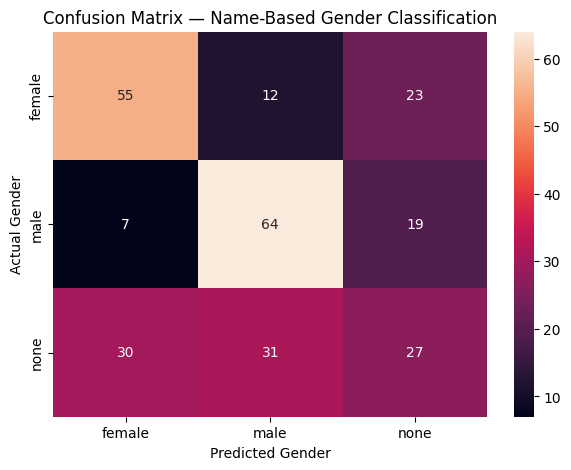

In [29]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_name_test,
    name_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_name.unique()),
    yticklabels=sorted(y_name.unique())
)

plt.title("Confusion Matrix — Name-Based Gender Classification")
plt.xlabel("Predicted Gender")
plt.ylabel("Actual Gender")

plt.show()

In [30]:
# ============================================
# COMBINED NAME + COMPANY + AGE MODEL
# ============================================

X_combined = users[
    ["name", "company", "age"]
]

y_combined = users["gender"]

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined,
    y_combined,
    test_size=0.20,
    random_state=42,
    stratify=y_combined
)

print("Training shape:", X_train_combined.shape)
print("Testing shape :", X_test_combined.shape)

Training shape: (1072, 3)
Testing shape : (268, 3)


In [31]:
# ============================================
# COMBINED PREPROCESSOR
# ============================================

name_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1
)

combined_preprocessor = ColumnTransformer(
    transformers=[
        (
            "name",
            name_vectorizer,
            "name"
        ),
        (
            "company",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            ["company"]
        ),
        (
            "age",
            StandardScaler(),
            ["age"]
        )
    ]
)

In [32]:
# ============================================
# COMBINED LOGISTIC REGRESSION
# ============================================

combined_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            combined_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

combined_pipeline.fit(
    X_train_combined,
    y_train_combined
)

combined_predictions = combined_pipeline.predict(
    X_test_combined
)

combined_accuracy = accuracy_score(
    y_test_combined,
    combined_predictions
)

print(
    "Combined Model Accuracy:",
    combined_accuracy
)

Combined Model Accuracy: 0.5522388059701493


In [33]:
# ============================================
# COMBINED MODEL REPORT
# ============================================

print(
    classification_report(
        y_test_combined,
        combined_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

      female     0.6087    0.6222    0.6154        90
        male     0.6000    0.7000    0.6462        90
        none     0.4085    0.3295    0.3648        88

    accuracy                         0.5522       268
   macro avg     0.5390    0.5506    0.5421       268
weighted avg     0.5400    0.5522    0.5434       268



In [34]:
# ============================================
# 5-FOLD CROSS VALIDATION
# ============================================

cv_scores = cross_val_score(
    combined_pipeline,
    X_combined,
    y_combined,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation accuracy scores:")
print(cv_scores)

print("\nMean CV Accuracy:",
      cv_scores.mean())

print("CV Standard Deviation:",
      cv_scores.std())

Cross-validation accuracy scores:
[0.48880597 0.40671642 0.38059701 0.40671642 0.48134328]

Mean CV Accuracy: 0.4328358208955224
CV Standard Deviation: 0.04376978596601547


In [35]:
# ============================================
# 5-FOLD WEIGHTED F1
# ============================================

f1_scores = cross_val_score(
    combined_pipeline,
    X_combined,
    y_combined,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("CV Weighted F1 scores:")
print(f1_scores)

print("\nMean CV Weighted F1:",
      f1_scores.mean())

print("CV F1 Standard Deviation:",
      f1_scores.std())

CV Weighted F1 scores:
[0.48755091 0.41803162 0.38766562 0.42040112 0.46105433]

Mean CV Weighted F1: 0.4349407193092258
CV F1 Standard Deviation: 0.03516249544155587


In [36]:
# ============================================
# NAME FREQUENCY ANALYSIS
# ============================================

name_frequency = (
    users["name"]
    .value_counts()
    .reset_index()
)

name_frequency.columns = [
    "name",
    "frequency"
]

display(
    name_frequency.head(20)
)

print(
    "Names appearing more than once:",
    (name_frequency["frequency"] > 1).sum()
)

print(
    "Maximum name frequency:",
    name_frequency["frequency"].max()
)

,name,frequency
0,Charlotte Johnson,2
1,David Robinson,2
2,Jason Fraser,1
3,Helen Warner,1
4,Melvin Lovejoy,1
5,Paul Rodriguez,1
6,Roy Braun,1
7,Joseph Holsten,1
8,Wilma Mcinnis,1
9,Paula Daniel,1


Names appearing more than once: 2
Maximum name frequency: 2


In [37]:
# ============================================
# NAME REPETITION DISTRIBUTION
# ============================================

print(
    users["name"]
    .value_counts()
    .value_counts()
    .sort_index()
)

count
1    1336
2       2
Name: count, dtype: int64


In [38]:
# ============================================
# REPEATED NAME DETAILS
# ============================================

repeated_names = (
    users[
        users["name"].duplicated(
            keep=False
        )
    ]
    .sort_values("name")
)

display(repeated_names)

,code,company,name,gender,age
316,316,4You,Charlotte Johnson,female,64
496,496,Monsters CYA,Charlotte Johnson,none,51
309,309,4You,David Robinson,male,33
946,946,Acme Factory,David Robinson,none,30


In [39]:
# ============================================
# MODEL COMPARISON
# ============================================

models = {
    "Baseline": baseline_model,
    "Logistic Regression (Company + Age)": logistic_pipeline,
    "Decision Tree (Company + Age)": dt_pipeline,
    "Random Forest (Company + Age)": rf_classification_pipeline,
    "Name TF-IDF Logistic Regression": name_pipeline,
    "Combined Name + Company + Age": combined_pipeline
}

results = []

for model_name, model in models.items():

    if "Name TF-IDF" in model_name:
        predictions = name_pipeline.predict(X_name_test)
        actual = y_name_test

    elif "Combined" in model_name:
        predictions = combined_pipeline.predict(X_test_combined)
        actual = y_test_combined

    else:
        predictions = model.predict(X_test)
        actual = y_test

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            actual,
            predictions
        ),
        "Precision": precision_score(
            actual,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            actual,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            actual,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

classification_results = pd.DataFrame(results)

classification_results = classification_results.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(classification_results)

,Model,Accuracy,Precision,Recall,F1
0,Combined Name + Company + Age,0.552239,0.540023,0.552239,0.543429
1,Name TF-IDF Logistic Regression,0.544776,0.530115,0.544776,0.534106
2,Logistic Regression (Company + Age),0.380597,0.383068,0.380597,0.348751
3,Decision Tree (Company + Age),0.335821,0.325582,0.335821,0.325577
4,Random Forest (Company + Age),0.320896,0.313467,0.320896,0.314428
5,Baseline,0.335821,0.112776,0.335821,0.168848


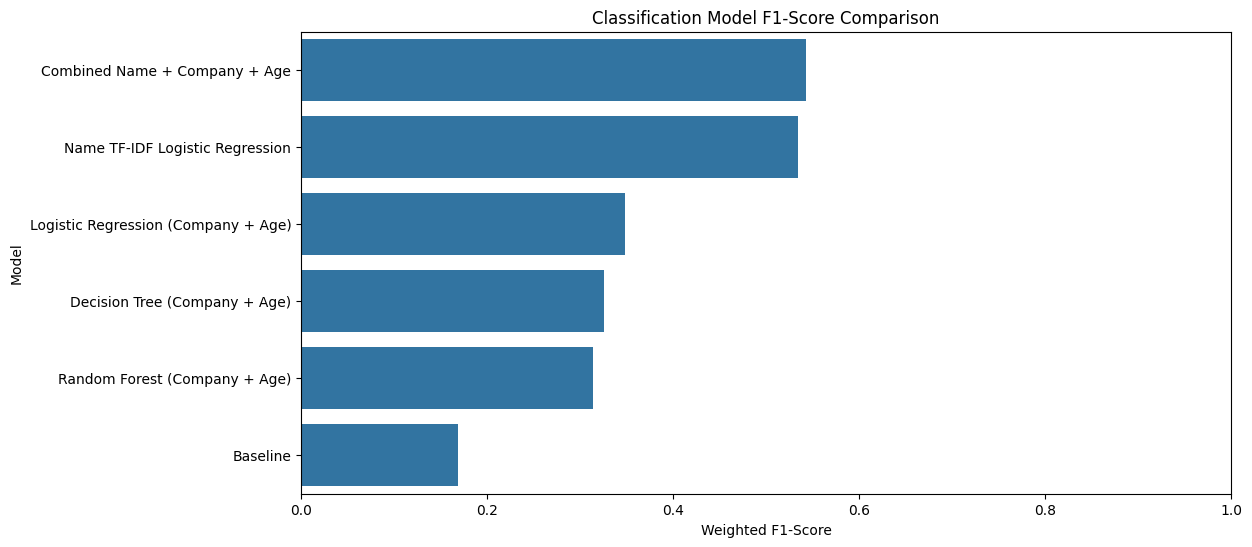

In [40]:
# ============================================
# MODEL F1 COMPARISON
# ============================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=classification_results,
    x="F1",
    y="Model"
)

plt.title("Classification Model F1-Score Comparison")
plt.xlabel("Weighted F1-Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


In [42]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [43]:
# ============================================
# MODEL COMPARISON
# ============================================

classification_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Name TF-IDF Logistic Regression",
        "Combined Name + Company + Age"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_predictions),
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_name_test, name_predictions),
        accuracy_score(y_test_combined, combined_predictions)
    ],
    "Weighted F1": [
        f1_score(y_test, baseline_predictions, average="weighted"),
        f1_score(y_test, logistic_predictions, average="weighted"),
        f1_score(y_test, dt_predictions, average="weighted"),
        f1_score(y_test, rf_predictions, average="weighted"),
        f1_score(y_name_test, name_predictions, average="weighted"),
        f1_score(y_test_combined, combined_predictions, average="weighted")
    ]
})

display(
    classification_results.sort_values(
        "Weighted F1",
        ascending=False
    )
)

,Model,Accuracy,Weighted F1
5,Combined Name + Company + Age,0.552239,0.543429
4,Name TF-IDF Logistic Regression,0.544776,0.534106
1,Logistic Regression,0.380597,0.348751
2,Decision Tree,0.335821,0.325577
3,Random Forest,0.320896,0.314428
0,Baseline,0.335821,0.168848


In [44]:
# ============================================
# HYPERPARAMETER TUNING
# ============================================

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    combined_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(
    X_train_combined,
    y_train_combined
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Weighted F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 100}

Best CV Weighted F1:
0.4961150067593385


In [45]:
# ============================================
# FINAL TUNED MODEL EVALUATION
# ============================================

final_classification_model = grid_search.best_estimator_

final_predictions = final_classification_model.predict(
    X_test_combined
)

final_accuracy = accuracy_score(
    y_test_combined,
    final_predictions
)

final_precision = precision_score(
    y_test_combined,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test_combined,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test_combined,
    final_predictions,
    average="weighted",
    zero_division=0
)

print("FINAL CLASSIFICATION MODEL")
print("--------------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

FINAL CLASSIFICATION MODEL
--------------------------
Accuracy : 0.5447761194029851
Precision: 0.5390828898810659
Recall   : 0.5447761194029851
F1 Score : 0.5413206278928141


In [46]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test_combined,
        final_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

      female     0.6067    0.6000    0.6034        90
        male     0.6122    0.6667    0.6383        90
        none     0.3951    0.3636    0.3787        88

    accuracy                         0.5448       268
   macro avg     0.5380    0.5434    0.5401       268
weighted avg     0.5391    0.5448    0.5413       268



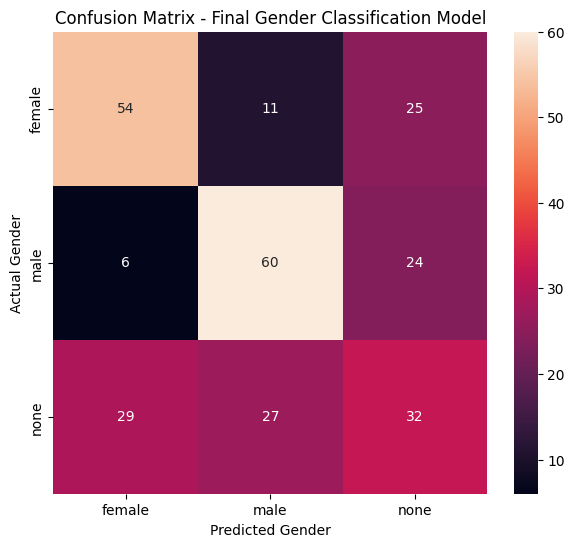

In [47]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test_combined,
    final_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_combined.unique()),
    yticklabels=sorted(y_combined.unique())
)

plt.title("Confusion Matrix - Final Gender Classification Model")
plt.xlabel("Predicted Gender")
plt.ylabel("Actual Gender")

plt.show()

In [48]:
# ============================================
# ERROR ANALYSIS
# ============================================

error_analysis = X_test_combined.copy()

error_analysis["Actual"] = y_test_combined.values
error_analysis["Predicted"] = final_predictions

errors = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("Total test samples:", len(error_analysis))
print("Incorrect predictions:", len(errors))

print(
    "Error percentage:",
    round(
        len(errors) / len(error_analysis) * 100,
        2
    ),
    "%"
)

display(errors.head(20))

Total test samples: 268
Incorrect predictions: 122
Error percentage: 45.52 %


,name,company,age,Actual,Predicted
361,Curtis Sexton,4You,33,male,none
748,Bradley Rhodes,Wonka Company,47,male,none
489,James Wareham,Monsters CYA,57,none,male
496,Charlotte Johnson,Monsters CYA,51,none,female
942,Delia Rodriguez,Acme Factory,26,none,female
119,Justin Bedard,4You,38,male,none
123,Ralph Alzugaray,4You,60,male,none
130,Robin Greek,4You,65,female,male
330,Robert Smith,4You,57,none,male
444,Jodi Norton,4You,37,none,male


In [49]:
# ============================================
# CONFUSION PAIRS
# ============================================

confusion_pairs = (
    errors
    .groupby(["Actual", "Predicted"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(confusion_pairs)

,Actual,Predicted,Count
4,none,female,29
5,none,male,27
1,female,none,25
3,male,none,24
0,female,male,11
2,male,female,6


In [50]:
# ============================================
# SAVE FINAL CLASSIFICATION MODEL
# ============================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/gender_classification_model.pkl"

joblib.dump(
    final_classification_model,
    model_path
)

print("Final classification model saved successfully!")
print("Path:", model_path)

Final classification model saved successfully!
Path: ../models/gender_classification_model.pkl


In [51]:
# ============================================
# VERIFY SAVED MODEL
# ============================================

loaded_gender_model = joblib.load(
    model_path
)

test_prediction = loaded_gender_model.predict(
    X_test_combined.head(5)
)

print("Model loaded successfully!")
print("Sample predictions:", test_prediction)

Model loaded successfully!
Sample predictions: ['male' 'male' 'none' 'none' 'male']
